# RNN model for Sentiment Analysis
## Samll Dataset 
https://data.world/datafiniti/consumer-reviews-of-amazon-products

## Methods
- display_confusion_matrix
- save_complete_model
- preprocess_data
- create_rnn_model
- train_and_evaluate
- plot_training_history

In [1]:
import numpy as np
import mlflow
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, BatchNormalization, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from keras.optimizers import *
import time
import os
import datetime
import json
import warnings
warnings.filterwarnings('ignore')

base_path = "/home/subha/aiwork/project"
mlflow_storage = "mlflow"
experiment_number = f"EXP_{str(int(time.time()))}"
os.mkdir(f"{base_path}/completed_models/{experiment_number}")


def display_confusion_matrix(confusion_matrix, 
                             rnn_type,
                           labels=['Negative', 'Positive'],
                           title='Confusion Matrix',
                           figsize=(10, 8),
                           normalize=False,
                           cmap='Blues',
                           save_path=None
                           ):
    """
    Display a confusion matrix with annotations and metrics
    
    Args:
        confusion_matrix: 2x2 numpy array containing confusion matrix values labels: List of labels for classes
        (default: ['Negative', 'Positive'])
        title: Title for the plot (default: 'Confusion Matrix') figsize: Tuple for figure size (default: (10, 8))
        normalize: Whether to normalize values to percentages (default: False) cmap: Color map for the heatmap (default: 'Blues')
        save_path: Path to save the figure (default: None)
        
    Returns:
        matplotlib figure object
    """
    # Create figure and axes
    fig, ax = plt.subplots(figsize=figsize,dpi=100)

    # Turn interactive plotting off
    #plt.ioff()
    
    # Normalize matrix if requested
    if normalize:
        confusion_matrix = (confusion_matrix.astype('float') / 
                          confusion_matrix.sum(axis=1)[:, np.newaxis])
        fmt = '.2%'
    else:
        fmt = 'd'
    
    # Create heatmap
    sns.heatmap(confusion_matrix, 
                annot=True,            # Show numbers in cells
                fmt=fmt,               # Number format
                cmap=cmap,             # Color scheme
                square=True,           # Square cells
                xticklabels=labels,    # X-axis labels
                yticklabels=labels,    # Y-axis labels
                ax=ax)                 # Axis to plot on
    
    # Calculate metrics
    tn, fp, fn, tp = confusion_matrix.ravel()
    total = tn + fp + fn + tp
    
    # Calculate key metrics
    accuracy = (tp + tn) / total
    precision = tp / (tp + fp) if (tp + fp) != 0 else 0
    recall = tp / (tp + fn) if (tp + fn) != 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0
    
    # Add metrics text
    metrics_text = (
        f'Accuracy: {accuracy:.3f}\n'
        f'Precision: {precision:.3f}\n'
        f'Recall: {recall:.3f}\n'
        f'F1 Score: {f1:.3f}'
    )
    
    # Add metrics box
    props = dict(boxstyle='round', facecolor='white', alpha=0.8)
    ax.text(1.5, 0.5, metrics_text,
            transform=ax.transAxes,
            bbox=props,
            fontsize=10,
            verticalalignment='center')
    
    # Customize plot
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    plt.title(title +'-'+ rnn_type)
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()

    #plt.show()
    
    # # Save figure if path provided
    # if save_path:
    #     plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig

def save_complete_model(model, model_type, custom_name=None):
    """
    Save the complete model including architecture, weights, and optimizer state
    
    Args:
        model: Keras model instance
        model_type (str): Type of the model
        custom_name (str, optional): Custom name for the model
        
    Returns:
        str: Path to the saved model
    """
    try:
        epoch_time = str(int(time.time()))
        model_name = f"{custom_name}.keras"
        save_path = os.path.join(base_path, "completed_models", experiment_number)
        model_path = os.path.join(save_path,model_name)
        
        # Save the complete model
        model.save(model_path)
        
        # Save additional metadata
        metadata = {
            "model_type": model_type,
            "save_date": datetime.datetime.now().isoformat(),
            "keras_version": tf.keras.__version__,
            "model_name": model_name
        }
        
        metadata_path = os.path.join(save_path, f"metadata_{custom_name}.json")
        with open(metadata_path, 'w') as f:
            json.dump(metadata, f, indent=4)
            
        print(f"Model successfully saved to: {save_path}")
        return save_path
        
    except Exception as e:
        print(f"Error saving complete model: {str(e)}")
        raise

def preprocess_data(texts, labels, tokenizer=None, max_words=5000, max_len=100):
    """
    Preprocess text data for RNN input
    """
    epoch_time = str(int(time.time()))
    tkn_name = f"tokenizer.json"
    save_path = os.path.join(base_path, "completed_models",experiment_number,tkn_name)

    # Tokenize texts
    if tokenizer is None:
        tokenizer = Tokenizer(num_words=max_words)
        tokenizer.fit_on_texts(texts)
        tokenizer_config = tokenizer.to_json()
        # Saving the Tokenizer
        with open(save_path, 'w', encoding='utf-8') as f:
            f.write(tokenizer_config)
    
    # Convert texts to sequences
    sequences = tokenizer.texts_to_sequences(texts)
    
    # Pad sequences
    padded_sequences = pad_sequences(sequences, maxlen=max_len)
    
    return padded_sequences, tokenizer


def create_rnn_model(rnn_type, max_words=5000, embedding_dim=100,learning_rate=0.001,number_of_neurons=32,activation='relu'):
    """
    Create RNN model based on specified type
    """
    print("=======================================================================================")
    print("I am in create_rnn_model")
    print("=======================================================================================")

    model = Sequential(name=rnn_type)
    model.add(Embedding(max_words, embedding_dim))
    
    # adding a LSTM layer 
    if rnn_type == 'simple':
        model.add(SimpleRNN(number_of_neurons, activation=activation))
    elif rnn_type == 'lstm':
        model.add(LSTM(number_of_neurons, return_sequences=False))
    else :
        model.add(GRU(number_of_neurons))
    BatchNormalization()
    model.add(Dropout(0.2))
    
    #adding a dense layer with activation function of relu
    model.add(Dense(int(number_of_neurons/2), activation=activation))
    BatchNormalization()
    model.add(Dropout(0.6))
    
    # adding the final output activation with activation function of softmax
    model.add(Dense(1, activation='sigmoid'))

    optimizer = Adam(learning_rate=learning_rate)
    
    model.compile(optimizer=optimizer,
                 loss='binary_crossentropy',
                 metrics=['accuracy'])
    
    return model

def train_and_evaluate(model, X_train, y_train, X_val, y_val, X_test, y_test, rnn_type, epochs=15,early_stopping_ind=False,batch_size=32):
    """
    Train model and evaluate performance
    """

    print("=======================================================================================")
    print("I am in train_and_evaluate")
    print("=======================================================================================")
    
    # Early stopping to prevent overfitting
    early_stopping = EarlyStopping(monitor='val_loss', 
                                 patience=3,
                                 restore_best_weights=True)
    
    # Variable rate
    lr_scheduler = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1, min_lr=1e-5)

    if early_stopping_ind:
        callbacks = [early_stopping,lr_scheduler]
    else:
        callbacks = [lr_scheduler]
    
    # Train model
    history = model.fit(X_train, 
                        y_train,
                        batch_size=batch_size,
                        epochs=epochs,
                        verbose=1,
                        validation_data=(X_val, y_val),
                        callbacks=callbacks
                       )
    
    # Evaluate on test set
    test_loss, test_accuracy = model.evaluate(X_test, y_test)
    
   # Model Summary
    model.summary()
    
    save_path = save_complete_model(
                        model=model,
                        model_type=rnn_type,
                        custom_name=f"sentiment_analysis_{rnn_type}"
                    )
    print(f"The Model is saved in {save_path}")
    
    # Generate predictions
    y_pred = (model.predict(X_test) > 0.5).astype(int)
    
    return history, test_loss, test_accuracy, y_pred

def plot_training_history(history, model_name):
    """
    Plot training and validation metrics
    """
    print("=======================================================================================")
    print("I am in plot_training_history")
    print("=======================================================================================")
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4),dpi=100)
    
    # Turn interactive plotting off
    #plt.ioff()
    
    # Plot accuracy
    #ax1.set_ylim(0, 1.5)
    ax1.plot(history.history['accuracy'])
    ax1.plot(history.history['val_accuracy'])
    ax1.set_title(f'{model_name} - Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'])
    
    # Plot loss
    ax2.plot(history.history['loss'])
    ax2.plot(history.history['val_loss'])
    ax2.set_title(f'{model_name} - Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'])
    
    plt.tight_layout()
    return fig




2025-03-30 09:20:28.834157: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-30 09:20:28.843757: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743340828.852336 3867722 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743340828.854817 3867722 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1743340828.862240 3867722 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## Compare Models

In [2]:
remote_server_uri = "http://172.22.74.11:5000/"
mlflow.set_tracking_uri(remote_server_uri)
def compare_models(X_train, y_train, X_val, X_test, y_val, y_test, vocab=5000,embedding_dim=100,learning_rate=0.001,epochs=15,early_stop=False,batch_size=32,activation_func='relu',number_of_neurons=32):
    """
    Compare different RNN architectures
    """
    results = {}
    model_types = ['simple', 'lstm', 'gru'] # Removed 'bilstm' for simplicity as attention mechanism wasn't clearly defined
    tokenizer = None # Initialize tokenizer here to use the same one across models

    for rnn_type in model_types:
        with mlflow.start_run(run_name=f"Sentiment Analysis - {rnn_type.upper()}"):
            print(f"Training model: {rnn_type.upper()}")
            mlflow.log_param("rnn_type", rnn_type)
            mlflow.log_param("vocab_size", vocab)
            mlflow.log_param("embedding_dim", embedding_dim)
            mlflow.log_param("learning_rate", learning_rate)
            mlflow.log_param("epochs", epochs)
            mlflow.log_param("early_stop", early_stop)
            mlflow.log_param("batch_size", batch_size)
            mlflow.log_param("activation_func", activation_func)
            mlflow.log_param("number_of_neurons", number_of_neurons)
            mlflow.log_param("data_size", 'small')

            model = create_rnn_model(rnn_type, 
                                     vocab, 
                                     embedding_dim, 
                                     learning_rate, 
                                     number_of_neurons, 
                                     activation_func) 
            
            history, test_loss, test_accuracy, y_pred = train_and_evaluate( model, 
                                                                            X_train, 
                                                                            y_train, 
                                                                            X_val, 
                                                                            y_val, 
                                                                            X_test,
                                                                            y_test, 
                                                                            rnn_type, 
                                                                            epochs, 
                                                                            early_stop, 
                                                                            batch_size
                                                                        )

            mlflow.log_metric("test_loss", test_loss)
            mlflow.log_metric("test_accuracy", test_accuracy)

            # Log training history metrics
            for epoch in range(len(history.history['loss'])):
                mlflow.log_metric("train_loss", history.history['loss'][epoch], step=epoch)
                mlflow.log_metric("val_loss", history.history['val_loss'][epoch], step=epoch)
                mlflow.log_metric("train_accuracy", history.history['accuracy'][epoch], step=epoch)
                mlflow.log_metric("val_accuracy", history.history['val_accuracy'][epoch], step=epoch)

            # Log classification report and confusion matrix as artifacts (or as json)
            report = classification_report(y_test, y_pred, target_names=['Negative', 'Positive'], output_dict=True)
            cm = confusion_matrix(y_test, y_pred)

            with open(f"{mlflow_storage}/classification_report_{rnn_type}.json", "w") as f:
                json.dump(report, f, indent=4)
            np.save(f"{mlflow_storage}/confusion_matrix_{rnn_type}.npy", cm)

            mlflow.log_artifact(f"{mlflow_storage}/classification_report_{rnn_type}.json")
            mlflow.log_artifact(f"{mlflow_storage}/confusion_matrix_{rnn_type}.npy")

            # Log the trained model
            mlflow.keras.log_model(model, f"model_{rnn_type}")

            results[rnn_type] = {
                'history': history,
                'test_loss': test_loss,
                'test_accuracy': test_accuracy,
                'predictions': y_pred,
                'classification report': report,
                'confusion_matrix': cm
            }

            # Plot training history and save as artifact
            # fig_history = plot_training_history(history, rnn_type.upper())
            # fig_history.savefig(f"{mlflow_storage}/training_history_{rnn_type}.png")
            # mlflow.log_artifact(f"{mlflow_storage}/training_history_{rnn_type}.png")
            # plt.close(fig_history)

            # Plot confusion matrix and save as artifact
            # fig_cm = display_confusion_matrix(cm, rnn_type.upper())
            # fig_cm.savefig(f"{mlflow_storage}/confusion_matrix_{rnn_type}.png")
            # mlflow.log_artifact(f"{mlflow_storage}/confusion_matrix_{rnn_type}.png")
            # plt.close(fig_cm)

    return results, tokenizer


## Read Sampled Data 

In [3]:
X_test_ = pd.read_parquet('output/cleandata/small/test_data_sample/', engine='pyarrow' )
X_train_ = pd.read_parquet('output/cleandata/small/train_data_sample/', engine='pyarrow' )
X_val_ = pd.read_parquet('output/cleandata/small/val_data_sample/', engine='pyarrow' )

## Tokenize the Datasets

In [4]:
## Train

X_text_train = list(X_train_["cleaned_text"])
y_train = np.array(X_train_['sentiment']).astype("int32")# X_train_[["sentiment"]]
X_train, tokenizer = preprocess_data(X_text_train, y_train)

## Test

X_text_test = list(X_test_["cleaned_text"])
y_test = np.array(X_test_['sentiment']).astype("int32")# X_train_[["sentiment"]]
X_test, tokenizer = preprocess_data(X_text_test, y_test, tokenizer)

## Val

X_text_val = list(X_val_["cleaned_text"])
y_val = np.array(X_val_['sentiment']).astype("int32")# X_train_[["sentiment"]]
X_val, tokenizer = preprocess_data(X_text_val, y_val, tokenizer)


vocab = len(tokenizer.word_index) + 1

In [5]:
print(X_train.shape, X_test.shape, X_val.shape, y_train.shape, y_test.shape, y_val.shape,vocab)

(22720, 100) (5612, 100) (5612, 100) (22720,) (5612,) (5612,) 11092


In [15]:
#results, tokenizer = compare_models(X_train, y_train, X_val, X_test, y_val, y_test, vocab)
results, tokenizer = compare_models(X_train, y_train, X_val, X_test, y_val, y_test, vocab
                                    ,embedding_dim=100
                                    ,learning_rate=0.001
                                    ,epochs=15
                                    ,early_stop=True
                                    ,batch_size=64
                                    ,activation_func='relu'
                                    ,number_of_neurons=64) 

Training model: SIMPLE
I am in create_rnn_model
I am in train_and_evaluate
Epoch 1/15
355/355 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8660 - loss: 0.3687 - val_accuracy: 0.9332 - val_loss: 0.1819 - learning_rate: 0.0010
Epoch 2/15
355/355 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9422 - loss: 0.1613 - val_accuracy: 0.9485 - val_loss: 0.1601 - learning_rate: 0.0010
Epoch 3/15
355/355 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9620 - loss: 0.1166 - val_accuracy: 0.9540 - val_loss: 0.1748 - learning_rate: 0.0010
Epoch 4/15
355/355 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9743 - loss: 0.0828 - val_accuracy: 0.9562 - val_loss: 0.1896 - learning_rate: 0.0010
Epoch 5/15
353/355 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9749 - loss: 0.0864
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
355/355 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9749 - loss: 0.0865 - val_accuracy: 0.9489 - val_loss: 0.1850 - learning_rate: 0.0010
176/176 

Model: "simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (64, 100, 100)         │     1,109,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (64, 64)               │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (64, 64)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (64, 32)               │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (64, 32)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (64, 1)                │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,365,621 (12.84 MB)

 Trainable params: 1,121,873 (4.28 MB)

...

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,286,372 (8.72 MB)

Model successfully saved to: /home/subha/aiwork/project/completed_models/EXP_1743340830
The Model is saved in /home/subha/aiwork/project/completed_models/EXP_1743340830
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step 


2025/03/30 14:09:19 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2025/03/30 14:09:23 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Sentiment Analysis - GRU at: http://172.22.74.11:5000/#/experiments/0/runs/3813f9328fb04e93a879d2438d8ede00
🧪 View experiment at: http://172.22.74.11:5000/#/experiments/0


## Evaluation

### Accuracy & Loss (Simple)

I am in plot_training_history


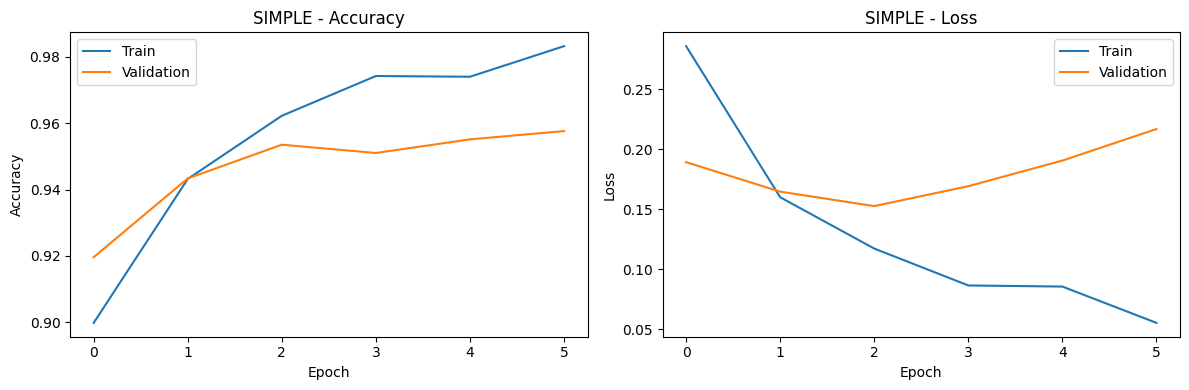

In [7]:
model_types = ['simple', 'lstm', 'gru']
plot_training_history(results[model_types[0]]["history"], model_types[0].upper()).show()

### Confusion Matrix (Simple)

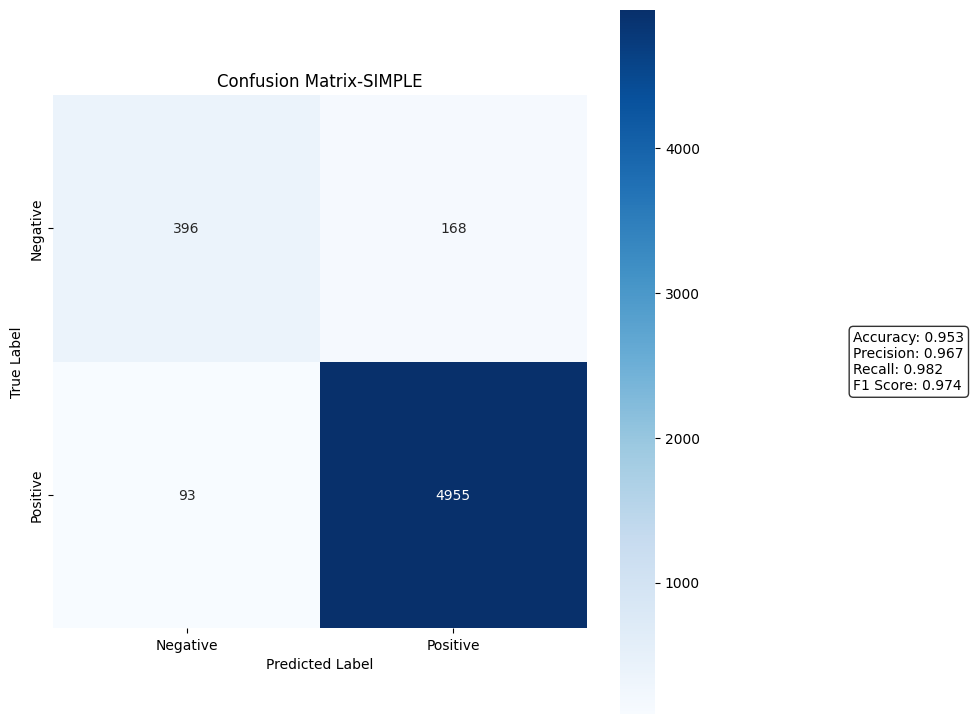

In [8]:
display_confusion_matrix(results[model_types[0]]["confusion_matrix"],model_types[0].upper()).show()

### Accuracy & Loss (LSTM)

I am in plot_training_history


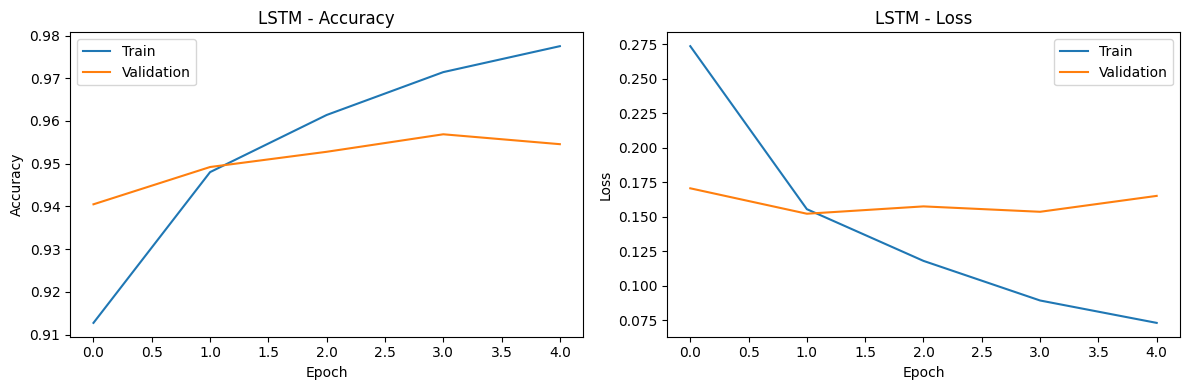

In [9]:
model_types = ['simple', 'lstm', 'gru']
plot_training_history(results[model_types[1]]["history"], model_types[1].upper()).show()

### Confusion Matrix(LSTM)

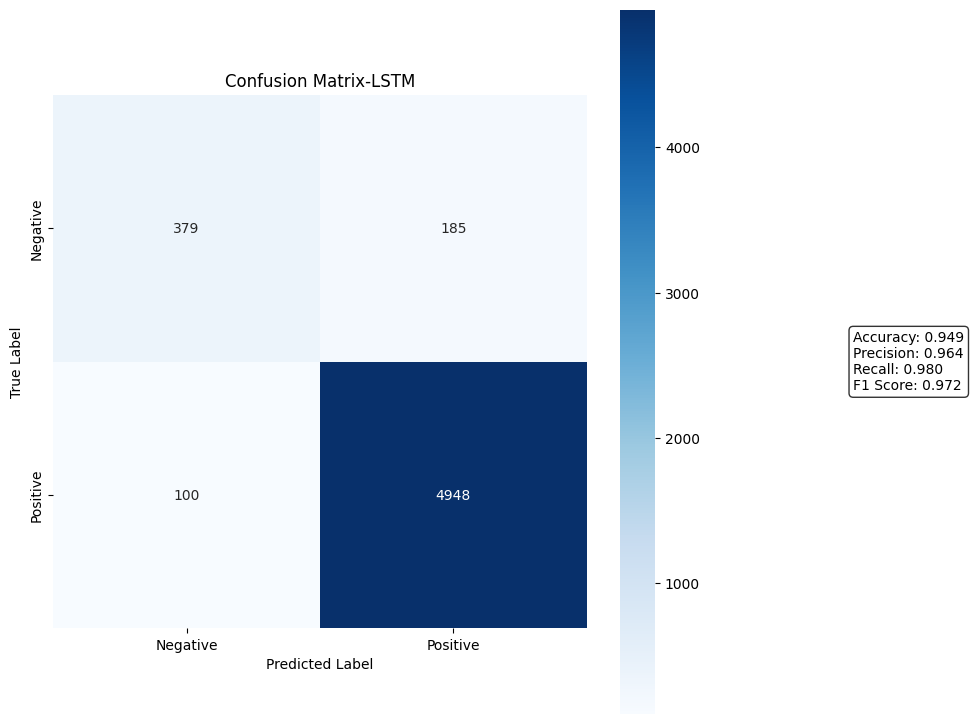

In [10]:
display_confusion_matrix(results[model_types[1]]["confusion_matrix"],model_types[1].upper()).show()

### Accuracy & Loss (GRU)

I am in plot_training_history


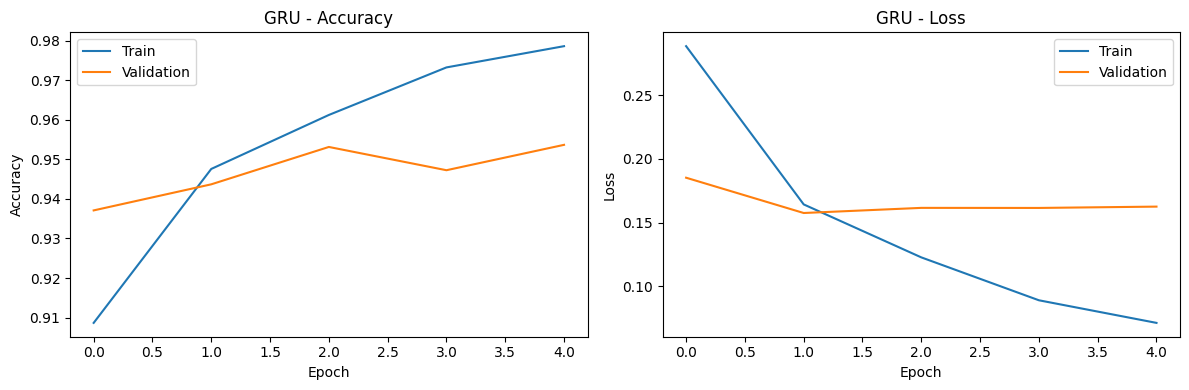

In [11]:
model_types = ['simple', 'lstm', 'gru']
plot_training_history(results[model_types[2]]["history"], model_types[2].upper()).show()

### Confusion Matrix (LSTM)

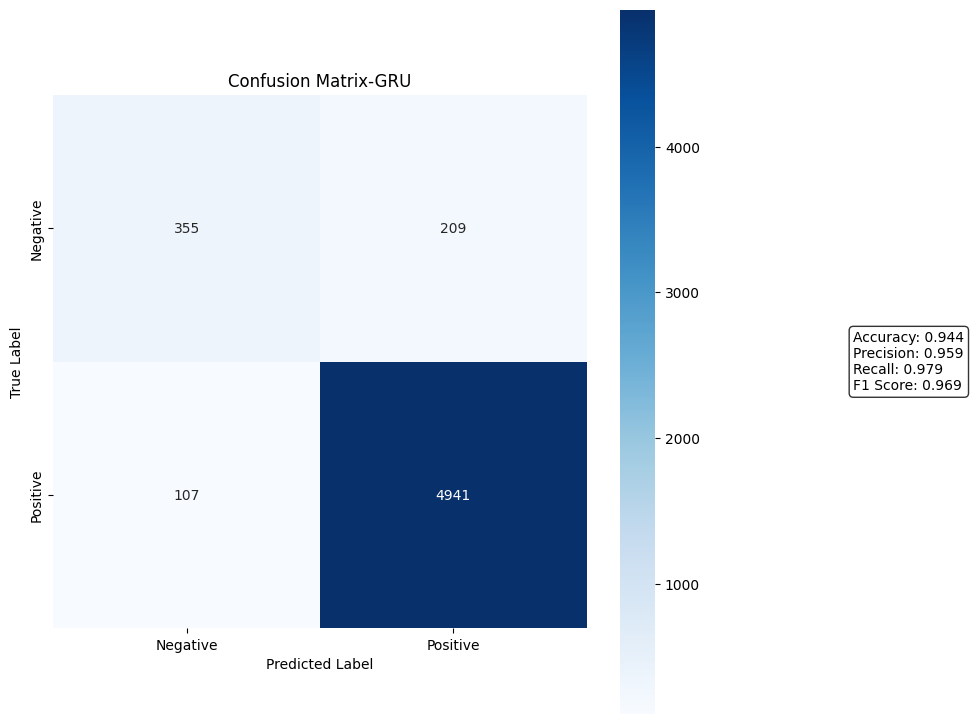

In [12]:
display_confusion_matrix(results[model_types[2]]["confusion_matrix"],model_types[2].upper()).show()

## Appendix

In [13]:
!nvidia-smi

Sun Mar 30 09:22:05 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.86.16              Driver Version: 572.16         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4070 ...    On  |   00000000:01:00.0 Off |                  N/A |
|  0%   42C    P2             30W /  220W |    2509MiB /  12282MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [14]:
!nvidia-smi  -L

GPU 0: NVIDIA GeForce RTX 4070 SUPER (UUID: GPU-40292fc1-c848-a256-79c7-1ec1a07d8fa8)
